# Terrain-Penalty WSE Extrapolation Example

Load the Bryant technical-note test rasters, clip them to a small wet AOI when needed, run CostGrow with the WhiteboxTools terrain-penalty backend, and fall back to PCRaster if WBT fails.

**Environment note:** run this notebook with the `dev` conda environment (`conda activate dev`).

## Imports

In [1]:
# Environment note for next time: run this notebook with conda env `dev`.
import os
import sys
import time
import logging
import shutil
import warnings
import importlib.metadata as metadata
from pathlib import Path

import numpy as np
import xarray as xr
import rioxarray
import rasterio
import scipy.ndimage
import matplotlib
import matplotlib.pyplot as plt
from rasterio.enums import Resampling
from rasterio.windows import Window, bounds as window_bounds

os.chdir('/workspace')
warnings.filterwarnings('ignore', message='IProgress not found.*')

from fdsc.alg.costGrow import downscale_costGrow_xr
from fdsc.hp.xr import resample_match_xr, xr_to_GeoTiff


## Paths And Controls

In [2]:
REPO_DIR = Path('/workspace')
DATA_DIR = REPO_DIR / 'tests' / 'data' / 'bryantTechnicalNoteResolution2024'
OUT_DIR = REPO_DIR / '_output' / 'examples' / 'terrain_penalty_wse_extrapolation'
RUN_DIR = OUT_DIR / 'costgrow_run'
OUT_DIR.mkdir(parents=True, exist_ok=True)
RUN_DIR.mkdir(parents=True, exist_ok=True)

DEM_FINE_FP = DATA_DIR / 'dem_04m.tif'
WSE_COARSE_FP = DATA_DIR / 'wse_32m.tif'
WSE_AFTER_FP = OUT_DIR / 'wse_terrain_penalty_after.tif'

USE_CLIP = False
MAX_FINE_CELLS = None
CLIP_COARSE_WINDOW = Window(col_off=129, row_off=75, width=160, height=80)
DISTANCE_FILL = 'terrain_penalty'
DISTANCE_FILL_METHOD = 'distance_transform_cdt'
DECAY_METHOD_D = {'linear': dict(decay_frac=0.005)}
DP_COARSE_PIXEL_MAX = 50
DEBUG_OUTPUTS = True
LOG_LEVEL = logging.DEBUG
DISPLAY_SHAPE = (450, 900)

print(f'workspace: {REPO_DIR}')
print(f'data directory: {DATA_DIR}')
print(f'output directory: {OUT_DIR}')
print(f'dem exists: {DEM_FINE_FP.exists()}')
print(f'wse exists: {WSE_COARSE_FP.exists()}')


workspace: /workspace
data directory: /workspace/tests/data/bryantTechnicalNoteResolution2024
output directory: /workspace/_output/examples/terrain_penalty_wse_extrapolation
dem exists: True
wse exists: True


## Environment And Raster Diagnostics

In [3]:
for package_name in ['numpy', 'xarray', 'rioxarray', 'rasterio', 'matplotlib', 'whitebox', 'pcraster']:
    try:
        print(f'{package_name}: {metadata.version(package_name)}')
    except metadata.PackageNotFoundError:
        print(f'{package_name}: not installed')

for fp in [DEM_FINE_FP, WSE_COARSE_FP]:
    with rasterio.open(fp) as src:
        print(fp.name)
        print(f'  shape: {(src.height, src.width)}')
        print(f'  cells: {src.height * src.width:,}')
        print(f'  crs: {src.crs}')
        print(f'  res: {src.res}')
        print(f'  nodata: {src.nodata}')

numpy: 2.4.3
xarray: 2026.4.0
rioxarray: 0.22.0
rasterio: 1.5.0
matplotlib: 3.10.9
whitebox: 2.3.6
pcraster: not installed
dem_04m.tif
  shape: (1664, 3360)
  cells: 5,591,040
  crs: EPSG:4647
  res: (4.0, 4.0)
  nodata: -9999.0
wse_32m.tif
  shape: (208, 420)
  cells: 87,360
  crs: EPSG:4647
  res: (32.0, 32.0)
  nodata: -9999.0


## Load And Clip

In [4]:
def load_da(fp):
    """Load a single-band raster and convert nodata values to NaN."""
    da = rioxarray.open_rasterio(fp, masked=False).squeeze().compute()
    nodata = da.rio.nodata
    if nodata is not None:
        da = da.where(da != nodata, np.nan)
    return da.rio.write_nodata(nodata).rio.write_crs(da.rio.crs)

if USE_CLIP:
    with rasterio.open(WSE_COARSE_FP) as wse_src:
        aoi_bounds = window_bounds(CLIP_COARSE_WINDOW, wse_src.transform)
    print('using clipped AOI because USE_CLIP=True')
else:
    with rasterio.open(WSE_COARSE_FP) as wse_src:
        aoi_bounds = wse_src.bounds
    print('using full raster extent because USE_CLIP=False')

dem_fine_xr = load_da(DEM_FINE_FP).rio.clip_box(*aoi_bounds)
wse_before_xr = load_da(WSE_COARSE_FP).rio.clip_box(*aoi_bounds)

print(f'aoi bounds: {tuple(round(v, 3) for v in aoi_bounds)}')
print(f'dem_fine_xr shape: {dem_fine_xr.shape}')
print(f'wse_before_xr shape: {wse_before_xr.shape}')
print(f'wse_before_xr wet cells: {int(wse_before_xr.notnull().sum()):,}')


using full raster extent because USE_CLIP=False
aoi bounds: (32357390.0, 5596180.0, 32370830.0, 5602836.0)
dem_fine_xr shape: (1664, 3360)
wse_before_xr shape: (208, 420)
wse_before_xr wet cells: 6,907


## Run Terrain-Penalty Extrapolation

In [5]:
logging.basicConfig(level=logging.INFO, format='%(levelname)s.%(name)s: %(message)s', force=True)
logger = logging.getLogger('terrain_penalty_example')
logger.setLevel(LOG_LEVEL)
logging.getLogger('rasterio').setLevel(logging.WARNING)

backend_errors = {}
for cd_backend in ['wbt', 'pcraster']:
    backend_run_dir = RUN_DIR / cd_backend
    if backend_run_dir.exists():
        shutil.rmtree(backend_run_dir)
    try:
        logger.info(f'running CostGrow with backend={cd_backend}, debug={DEBUG_OUTPUTS}')
        start = time.perf_counter()
        wse_after_xr, meta_d = downscale_costGrow_xr(
            dem_fine_xr,
            wse_before_xr,
            logger=logger,
            distance_fill=DISTANCE_FILL,
            distance_fill_method=DISTANCE_FILL_METHOD,
            cd_backend=cd_backend,
            decay_method_d=DECAY_METHOD_D,
            dp_coarse_pixel_max=DP_COARSE_PIXEL_MAX,
            write_meta=True,
            debug=DEBUG_OUTPUTS,
            out_dir=str(backend_run_dir),
        )
        elapsed = time.perf_counter() - start
        selected_backend = cd_backend
        selected_run_dir = backend_run_dir
        break
    except Exception as err:
        backend_errors[cd_backend] = repr(err)
        logger.exception(f'backend={cd_backend} failed')
else:
    raise RuntimeError(f'all terrain-penalty backends failed: {backend_errors}')

xr_to_GeoTiff(wse_after_xr, str(WSE_AFTER_FP), log=logger.getChild('write'))

print(f'selected backend: {selected_backend}')
print(f'elapsed seconds: {elapsed:,.3f}')
print(f'after wet cells: {int(wse_after_xr.notnull().sum()):,}')
print(f'output raster: {WSE_AFTER_FP}')
print(f'backend run directory: {selected_run_dir}')
print(f'debug intermediates: {DEBUG_OUTPUTS}')
print(f'fallback errors: {backend_errors}')
print('metadata sample:')
for key in sorted(meta_d)[:25]:
    print(f'  {key}: {meta_d[key]}')


INFO.terrain_penalty_example: running CostGrow with backend=wbt, debug=True


DEBUG.terrain_penalty_example.costGrow: 00_inputs


DEBUG.terrain_penalty_example.costGrow: out_dir set to 
    /workspace/_output/examples/terrain_penalty_wse_extrapolation/costgrow_run/wbt


DEBUG.terrain_penalty_example.costGrow: wrote xr.DataArray (1, 208, 420) to 
    /workspace/_output/examples/terrain_penalty_wse_extrapolation/costgrow_run/wbt/00_inputs_wse_coarse_0208x0420.tif


DEBUG.terrain_penalty_example.costGrow: wrote xr.DataArray (1, 1664, 3360) to 
    /workspace/_output/examples/terrain_penalty_wse_extrapolation/costgrow_run/wbt/00_inputs_dem_fine_1664x3360.tif


...

DEBUG.terrain_penalty_example.costGrow: wse_to_wsh_xr on (1664, 3360)


DEBUG.terrain_penalty_example.costGrow: wrote xr.DataArray (1, 1664, 3360) to 
    /workspace/_output/examples/terrain_penalty_wse_extrapolation/costgrow_run/wbt/04_isol_wsh_fine_1664x3360.tif


DEBUG.terrain_penalty_example.costGrow: finished w/ {'00_inputs_wse_coarse': '/workspace/_output/examples/terrain_penalty_wse_extrapolation/costgrow_run/wbt/00_inputs_wse_coarse_0208x0420.tif', '00_inputs_dem_fine': '/workspace/_output/examples/terrain_penalty_wse_extrapolation/costgrow_run/wbt/00_inputs_dem_fine_1664x3360.tif', 'downscale': 8, 'fine_shape': (1664, 3360), 'coarse_shape': (208, 420), 'start': datetime.datetime(2026, 5, 1, 11, 8, 1, 983629), 'dem_mask_cnt': np.int64(0), 'wse_coarse_wet_cnt': np.int64(6907), 'debug': True, '01_resamp_wse_fine': '/workspace/_output/examples/terrain_penalty_wse_extrapolation/costgrow_run/wbt/01_resamp_wse_fine_1664x3360.tif', '02_wp_wse_fine': '/workspace/_output/examples/terrain_penalty_wse_extrapolation/costgrow_run/wbt/02_wp_wse_fine_1664x3360.tif', '03_dp_0distance': '/workspace/_output/examples/terrain_penalty_wse_extrapolation/costgrow_run/wbt/03_dp_0distance_1664x3360.tif', '03_dp_00linear_decay_0.005000_fp': '/workspace/_output/exam

DEBUG.terrain_penalty_example.write: wrote xr.DataArray (1, 1664, 3360) to 
    /workspace/_output/examples/terrain_penalty_wse_extrapolation/wse_terrain_penalty_after.tif


selected backend: wbt
elapsed seconds: 5.115
after wet cells: 444,812
output raster: /workspace/_output/examples/terrain_penalty_wse_extrapolation/wse_terrain_penalty_after.tif
backend run directory: /workspace/_output/examples/terrain_penalty_wse_extrapolation/costgrow_run/wbt
debug intermediates: True
fallback errors: {}
metadata sample:
  00_inputs_dem_fine: /workspace/_output/examples/terrain_penalty_wse_extrapolation/costgrow_run/wbt/00_inputs_dem_fine_1664x3360.tif
  00_inputs_wse_coarse: /workspace/_output/examples/terrain_penalty_wse_extrapolation/costgrow_run/wbt/00_inputs_wse_coarse_0208x0420.tif
  01_resamp_wse_fine: /workspace/_output/examples/terrain_penalty_wse_extrapolation/costgrow_run/wbt/01_resamp_wse_fine_1664x3360.tif
  02_wp_wse_fine: /workspace/_output/examples/terrain_penalty_wse_extrapolation/costgrow_run/wbt/02_wp_wse_fine_1664x3360.tif
  03_dp_00linear_decay_0.005000_fp: /workspace/_output/examples/terrain_penalty_wse_extrapolation/costgrow_run/wbt/decay/03_dp

## Plot DEM, Decay, Cost Distance, And WSE


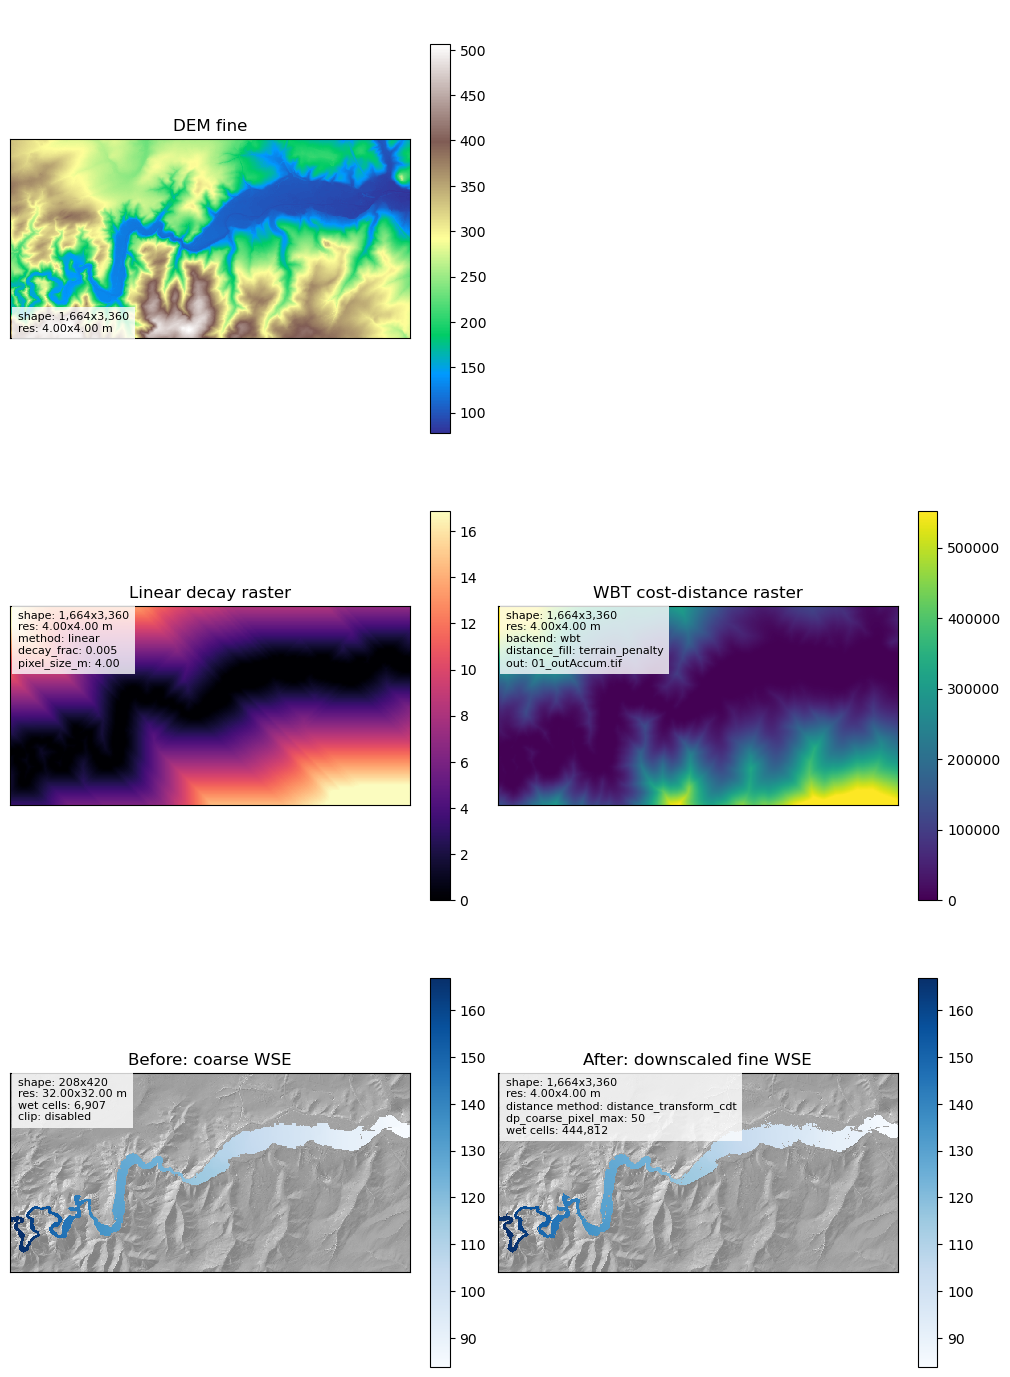

In [6]:
def downsample_for_display(ar, target_shape=DISPLAY_SHAPE):
    """Nearest-neighbor resample an array for display only."""
    assert ar.ndim == 2
    if target_shape is None or ar.shape == tuple(target_shape):
        return ar
    yi = np.clip(np.round(np.linspace(0, ar.shape[0] - 1, target_shape[0])).astype(int), 0, ar.shape[0] - 1)
    xi = np.clip(np.round(np.linspace(0, ar.shape[1] - 1, target_shape[1])).astype(int), 0, ar.shape[1] - 1)
    return ar[np.ix_(yi, xi)]

def load_output_da(fp, template_da=None):
    """Load a debug GeoTIFF and normalize its nodata values to NaN."""
    da = rioxarray.open_rasterio(fp, masked=False).squeeze().compute()
    nodata = da.rio.nodata
    if nodata is not None:
        da = da.where(da != nodata, np.nan)
    if da.rio.crs is None and template_da is not None:
        da = da.rio.write_crs(template_da.rio.crs)
    return da

def build_hillshade(da, azimuth=315.0, altitude=45.0):
    """Build a simple normalized hillshade from a DEM DataArray."""
    ar = np.asarray(da.data, dtype=float)
    filled_ar = np.where(np.isfinite(ar), ar, np.nanmean(ar))
    res_x, res_y = np.abs(da.rio.resolution())
    gy, gx = np.gradient(filled_ar, res_y, res_x)
    slope = np.pi / 2.0 - np.arctan(np.hypot(gx, gy))
    aspect = np.arctan2(-gx, gy)
    azimuth_rad = np.deg2rad(azimuth)
    altitude_rad = np.deg2rad(altitude)
    shade = (
        np.sin(altitude_rad) * np.sin(slope)
        + np.cos(altitude_rad) * np.cos(slope) * np.cos(azimuth_rad - aspect)
    )
    shade = (shade - np.nanmin(shade)) / (np.nanmax(shade) - np.nanmin(shade))
    return xr.DataArray(shade, coords=da.coords, dims=da.dims, attrs=da.attrs.copy()).rio.write_crs(da.rio.crs)

def add_panel_text(ax, da, extra_text=None, loc='lower_left'):
    """Add shape/resolution diagnostics and optional panel-specific parameters."""
    res_x, res_y = da.rio.resolution()
    text = f'shape: {da.shape[0]:,}x{da.shape[1]:,}\nres: {abs(res_x):.2f}x{abs(res_y):.2f} m'
    if extra_text:
        text = text + '\n' + extra_text
    y = 0.02 if loc == 'lower_left' else 0.98
    va = 'bottom' if loc == 'lower_left' else 'top'
    ax.text(
        0.02,
        y,
        text,
        transform=ax.transAxes,
        ha='left',
        va=va,
        fontsize=8,
        bbox={'facecolor': 'white', 'alpha': 0.8, 'edgecolor': 'none'},
    )

def plot_raster(ax, da, title, cmap='viridis', vmin=None, vmax=None, target_shape=DISPLAY_SHAPE, underlay_da=None, underlay_alpha=0.5, alpha=None, extra_text=None, text_loc='lower_left'):
    """Plot a raster DataArray with optional hillshade underlay."""
    if underlay_da is not None:
        underlay_ar = downsample_for_display(np.asarray(underlay_da.data, dtype=float), target_shape=target_shape)
        underlay_bounds = underlay_da.rio.bounds()
        ax.imshow(
            underlay_ar,
            extent=(underlay_bounds[0], underlay_bounds[2], underlay_bounds[1], underlay_bounds[3]),
            cmap='Greys',
            interpolation='nearest',
            origin='upper',
            aspect='equal',
            alpha=underlay_alpha,
        )

    ar = downsample_for_display(np.asarray(da.data, dtype=float), target_shape=target_shape)
    bounds = da.rio.bounds()
    im = ax.imshow(
        ar,
        extent=(bounds[0], bounds[2], bounds[1], bounds[3]),
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        interpolation='nearest',
        origin='upper',
        aspect='equal',
        alpha=alpha,
    )
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    add_panel_text(ax, da, extra_text=extra_text, loc=text_loc)
    return im

# Rebuild decay and cost-distance diagnostics for plotting.
wse_fine_resampled_xr = resample_match_xr(wse_before_xr, dem_fine_xr, resampling=Resampling.bilinear)
wse_wet_partial_xr = wse_fine_resampled_xr.where(wse_fine_resampled_xr > dem_fine_xr)
pixel_size_m = float(np.abs(dem_fine_xr.rio.resolution()).mean())
distance_ar = scipy.ndimage.distance_transform_cdt(
    wse_wet_partial_xr.isnull().data.astype(int),
    return_distances=True,
    return_indices=False,
) * pixel_size_m
decay_frac = DECAY_METHOD_D['linear']['decay_frac']
decay_ar = np.where(wse_wet_partial_xr.isnull().data, distance_ar * decay_frac, 0.0)
decay_xr = xr.DataArray(
    decay_ar,
    coords=dem_fine_xr.coords,
    dims=dem_fine_xr.dims,
    attrs=dem_fine_xr.attrs.copy(),
).rio.write_nodata(dem_fine_xr.rio.nodata).rio.write_crs(dem_fine_xr.rio.crs)

cost_distance_fp = selected_run_dir / selected_backend / '01_outAccum.tif'
cost_distance_xr = load_output_da(cost_distance_fp, template_da=dem_fine_xr)
hillshade_xr = build_hillshade(dem_fine_xr)

wse_cmap = plt.get_cmap('Blues').copy()
wse_cmap.set_bad(alpha=0.0)
wse_values = np.concatenate([
    np.ravel(wse_before_xr.data[np.isfinite(wse_before_xr.data)]),
    np.ravel(wse_after_xr.data[np.isfinite(wse_after_xr.data)]),
])
wse_vmin, wse_vmax = np.nanpercentile(wse_values, [2, 98])
decay_vmax = float(np.nanpercentile(decay_xr.data, 98))
cost_vmax = float(np.nanpercentile(cost_distance_xr.data[np.isfinite(cost_distance_xr.data)], 98))
clip_note = 'disabled' if not USE_CLIP else f'{CLIP_COARSE_WINDOW.width:.0f}x{CLIP_COARSE_WINDOW.height:.0f} coarse px'
decay_text = f'method: linear\ndecay_frac: {decay_frac:.3f}\npixel_size_m: {pixel_size_m:.2f}'
cost_text = f'backend: {selected_backend}\ndistance_fill: {DISTANCE_FILL}\nout: 01_outAccum.tif'
coarse_text = f'wet cells: {int(wse_before_xr.notnull().sum()):,}\nclip: {clip_note}'
after_text = f'distance method: {DISTANCE_FILL_METHOD}\ndp_coarse_pixel_max: {DP_COARSE_PIXEL_MAX}\nwet cells: {int(wse_after_xr.notnull().sum()):,}'

fig, axes = plt.subplots(3, 2, figsize=(10, 14), constrained_layout=True)

im0 = plot_raster(axes[0, 0], dem_fine_xr, 'DEM fine', cmap='terrain')
fig.colorbar(im0, ax=axes[0, 0], shrink=0.85)

axes[0, 1].axis('off')
axes[0, 1].set_title('')

im1 = plot_raster(axes[1, 0], decay_xr, 'Linear decay raster', cmap='magma', vmin=0.0, vmax=decay_vmax, extra_text=decay_text, text_loc='upper_left')
fig.colorbar(im1, ax=axes[1, 0], shrink=0.85)

im2 = plot_raster(axes[1, 1], cost_distance_xr, 'WBT cost-distance raster', cmap='viridis', vmin=0.0, vmax=cost_vmax, extra_text=cost_text, text_loc='upper_left')
fig.colorbar(im2, ax=axes[1, 1], shrink=0.85)

im3 = plot_raster(axes[2, 0], wse_before_xr, 'Before: coarse WSE', cmap=wse_cmap, vmin=wse_vmin, vmax=wse_vmax, underlay_da=hillshade_xr, underlay_alpha=0.5, extra_text=coarse_text, text_loc='upper_left')
fig.colorbar(im3, ax=axes[2, 0], shrink=0.85)

im4 = plot_raster(axes[2, 1], wse_after_xr, 'After: downscaled fine WSE', cmap=wse_cmap, vmin=wse_vmin, vmax=wse_vmax, underlay_da=hillshade_xr, underlay_alpha=0.5, extra_text=after_text, text_loc='upper_left')
fig.colorbar(im4, ax=axes[2, 1], shrink=0.85)

plt.show()
